# NB02b — MGnify mobility prediction (Exploratory)

**Status:** Exploratory analysis. Tests H5, H6, H7 on MGnify dataset.

**Goal:** Test hypotheses H5, H6, H7 via spatial block CV on MGnify MAGs, mirroring NB02 for SPIRE.

**Hypotheses:**
- **H5:** MGnify M3 (KO + soil) outperforms B0 (baseline RMSE) — positive control check
- **H6:** MGnify M3 outperforms M2 (soil-only) — KO features add explanatory value
- **H7:** MGnify M3 generalises across geographic hold-out sets (RMSE < B0 + 0.01)

Matches NB02 (SPIRE) pipeline. Target is PF1_Cu.

**Models:**
- B0: mean predictor
- M1: KO density features only
- M2: SoilGrids soil properties (ph_h2o, organic_carbon_density, clay_content) — from REST API; partial coverage for non-soil biomes
- M3: M1 + M2 combined

**Primary target:** `PF1_Cu` (CSU metal mobility fraction; soil Cu geochemistry).

**Output:** `data/mgnify_mobility_prediction_results.csv`, `data/mgnify_shap_mean_abs.csv`.


In [1]:
print("NB02b executing — predicting MGnify mobility from MAG genomic density (exploratory).")

NB02b executing — predicting MGnify mobility from MAG genomic density (exploratory).


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / 'scripts'))
from modelling import (
    MAG_DENSITY_FEATURES, NON_METAL_FEATURES, ALL_FEATURES, CSU_TARGETS,
    make_spatial_folds, spatial_block_cv, summarise_cv, build_xgboost,
)
from evaluation import (
    compute_shap_values, plot_shap_bar, shap_metal_fraction,
    format_cv_table,
)

sys.path.insert(0, '/home/hmacgregor/BERIL-research-observatory/tools')
from figure_style import apply_style, save
apply_style()

DATA_DIR = Path.cwd().parent / 'data'
FIG_DIR = Path.cwd().parent / 'figures'
FIG_DIR.mkdir(exist_ok=True)

In [3]:
# Load MGnify feature matrix
df = pd.read_csv(DATA_DIR / 'mgnify_mag_feature_matrix.csv')
TARGET = 'PF1_Cu'

# Detect subcategory density columns
subcat_density_cols = [c for c in df.columns if c.startswith('ko_per_mb_') and c != 'ko_per_mb_primary']
MAG_ALL_DENSITY = MAG_DENSITY_FEATURES + subcat_density_cols
print(f"MAG density features: {MAG_ALL_DENSITY}")

# SoilGrids columns for M2 (may be partially present depending on API coverage)
SG_COLS = [c for c in NON_METAL_FEATURES if c in df.columns]
print(f"SoilGrids columns available: {SG_COLS}")
if SG_COLS:
    sg_coverage = df[SG_COLS[0]].notna().sum()
    print(f"SoilGrids coverage: {sg_coverage}/{len(df)} MAGs ({100*sg_coverage/len(df):.0f}%)")

# Drop rows missing target + coordinates + M1 features
# SoilGrids (M2) intentionally not required here — spatial_block_cv handles per-model dropna
required_cols = [TARGET, 'latitude', 'longitude'] + MAG_ALL_DENSITY
df_clean = df.dropna(subset=[c for c in required_cols if c in df.columns]).copy()

print(f"Clean rows for modelling (B0/M1): {len(df_clean):,}")
print(f"Target ({TARGET}) distribution:")
print(df_clean[TARGET].describe())


MAG density features: ['ko_per_mb_primary', 'ko_per_mb_resistance', 'ko_per_mb_transport', 'ko_per_mb_sensing', 'ko_per_mb_metabolism', 'ko_per_mb_cofactor']
SoilGrids columns available: ['ph_h2o', 'organic_carbon_density', 'clay_content']
SoilGrids coverage: 5281/8849 MAGs (60%)
Clean rows for modelling (B0/M1): 7,973
Target (PF1_Cu) distribution:
count    7973.000000
mean        0.092979
std         0.035096
min         0.038029
25%         0.071941
50%         0.085543
75%         0.100837
max         0.395291
Name: PF1_Cu, dtype: float64


In [4]:
# M1: MAG genomic density features only
# M2: SoilGrids soil properties (ph_h2o, organic_carbon_density, clay_content)
# M3: M1 + M2 combined
SG_COLS_CLEAN = [c for c in NON_METAL_FEATURES if c in df_clean.columns]

FEATURE_SETS = {
    'B0': [],
    'M1': MAG_ALL_DENSITY,
    'M2': SG_COLS_CLEAN,
    'M3': MAG_ALL_DENSITY + SG_COLS_CLEAN,
}
# Filter to cols present in df_clean
FEATURE_SETS = {k: [c for c in v if c in df_clean.columns] for k, v in FEATURE_SETS.items()}
print("Feature sets (filtered to available columns):")
for k, v in FEATURE_SETS.items():
    print(f"  {k}: {v}")

if not SG_COLS_CLEAN:
    print("\nWARNING: No SoilGrids columns found — M2 and M3 will equal B0 and M1 respectively.")
    print("Ensure mgnify_mag_feature_matrix.csv contains ph_h2o/organic_carbon_density/clay_content.")


Feature sets (filtered to available columns):
  B0: []
  M1: ['ko_per_mb_primary', 'ko_per_mb_resistance', 'ko_per_mb_transport', 'ko_per_mb_sensing', 'ko_per_mb_metabolism', 'ko_per_mb_cofactor']
  M2: ['ph_h2o', 'organic_carbon_density', 'clay_content']
  M3: ['ko_per_mb_primary', 'ko_per_mb_resistance', 'ko_per_mb_transport', 'ko_per_mb_sensing', 'ko_per_mb_metabolism', 'ko_per_mb_cofactor', 'ph_h2o', 'organic_carbon_density', 'clay_content']


In [5]:
# Spatial block CV
cv_results = spatial_block_cv(
    df=df_clean,
    feature_sets=FEATURE_SETS,
    target_col=TARGET,
)
cv_summary = summarise_cv(cv_results)

cv_results.to_csv(DATA_DIR / 'mgnify_mobility_prediction_results.csv', index=False)
print(format_cv_table(cv_summary, model_order=['B0', 'M1', 'M2', 'M3']).to_string(index=False))

model RMSE (mean ± SD) R² (mean ± SD)  n_folds
   B0    0.037 ± 0.015 -0.083 ± 0.080        5
   M1    0.039 ± 0.013 -0.231 ± 0.165        5
   M2    0.037 ± 0.009 -0.381 ± 0.790        5
   M3    0.039 ± 0.008 -0.523 ± 0.876        5


In [6]:
rmse = cv_summary.set_index('model')['mean_rmse']
print("\nHypothesis tests (MGnify):")
if 'B0' in rmse.index:
    print("H5 (M3 < B0):", "SUPPORTED" if rmse['M3'] < rmse['B0'] else "NOT SUPPORTED")
if 'M2' in rmse.index:
    print("H6 (M3 < M2):", "SUPPORTED" if rmse['M3'] < rmse['M2'] else "NOT SUPPORTED")
if 'B0' in rmse.index:
    b0_rmse = rmse['B0']
    h7_threshold = b0_rmse + 0.01
    print(f"H7 (M3 < B0 + 0.01): SUPPORTED" if rmse['M3'] < h7_threshold else "NOT SUPPORTED", 
          f"(M3={rmse['M3']:.4f}, threshold={h7_threshold:.4f})")


Hypothesis tests (MGnify):
H5 (M3 < B0): NOT SUPPORTED
H6 (M3 < M2): NOT SUPPORTED
H7 (M3 < B0 + 0.01): SUPPORTED (M3=0.0387, threshold=0.0469)


MAG density SHAP fraction in M3: 5.4%


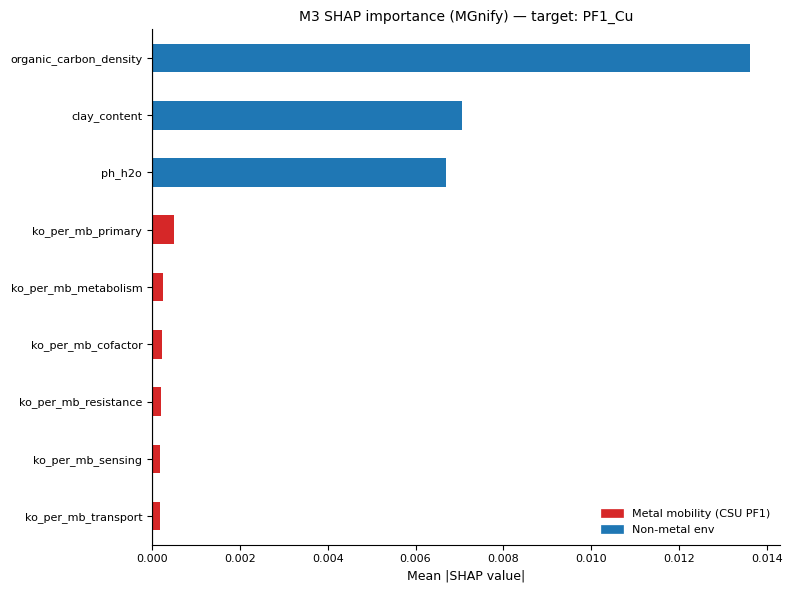

In [7]:
# SHAP on M3 (full model) to measure feature contribution
m3_features = FEATURE_SETS['M3']
valid_rows = df_clean.dropna(subset=m3_features + [TARGET])
if len(valid_rows) > 0:
    X_shap = valid_rows[m3_features]
    y_shap = valid_rows[TARGET].values

    m3_full = build_xgboost()
    m3_full.fit(X_shap.values, y_shap)

    shap_values, mean_shap = compute_shap_values(m3_full, X_shap)
    mean_shap.to_csv(DATA_DIR / 'mgnify_shap_mean_abs.csv')

    metal_frac = shap_metal_fraction(mean_shap, MAG_ALL_DENSITY)
    print(f"MAG density SHAP fraction in M3: {metal_frac:.1%}")

    plot_shap_bar(
        mean_shap,
        title=f"M3 SHAP importance (MGnify) — target: {TARGET}",
        metal_features=MAG_ALL_DENSITY,
        output_path=str(FIG_DIR / 'nb02b_shap_bar.pdf'),
    )
else:
    print("Not enough rows for SHAP analysis.")

In [8]:
# Plot CV RMSE
model_order = [m for m in ['B0', 'M1', 'M2', 'M3'] if m in cv_summary['model'].values]
if len(model_order) > 0:
    plot_data = cv_summary.set_index('model').reindex(model_order)

    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(len(model_order))
    colours = ['#aec7e8'] * 1 + ['#d62728'] * (len(model_order) - 1)
    ax.bar(x, plot_data['mean_rmse'], yerr=plot_data['sd_rmse'],
           color=colours, capsize=4, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order)
    ax.set_ylabel('Mean RMSE (5-fold spatial CV)')
    ax.set_title(f'CV RMSE by model (MGnify) — target: {TARGET}')
    plt.tight_layout()
    save(fig, FIG_DIR / 'nb02b_cv_rmse')